Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Demo 12 - Machine Learning

"All models are wrong, but some are useful." (George Box, 1976)

How would you prefer your model to be wrong so that it is most useful?

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn import tree

import demo12

%load_ext autoreload
%autoreload 2

# Data Loading and Wrangling

In [2]:
# Load filings
df = pd.read_csv('District_Court_of_Maryland_Eviction_Case_Data_MG_PG.csv', low_memory=False)

In [3]:
df

,Unnamed: 0,Event Date,Event Type,Event Comment,County,Location,Tenant City,Tenant State,Tenant ZIP Code,Case Type,Case Number,Evicted Date,Event Year,Eviction Year
0,535,01/03/2023,Warrant of Restitution - Return of Service - E...,NaN,Montgomery,Rockville,Silver Spring,MD,20910.0,Failure to Pay Rent,D-061-LT-22-004107,12/08/2022,2023,2022.0
1,536,01/03/2023,Warrant of Restitution - Return of Service - E...,NaN,Montgomery,Rockville,Silver Spring,MD,20910.0,Failure to Pay Rent,D-061-LT-22-000755,12/08/2022,2023,2022.0
2,545,01/03/2023,Warrant of Restitution - Return of Service - E...,NaN,Montgomery,Rockville,Bethesda,MD,20814.0,Failure to Pay Rent,D-061-LT-22-000816,12/07/2022,2023,2022.0
3,555,01/03/2023,Warrant of Restitution - Return of Service - E...,NaN,Montgomery,Rockville,Silver Spring,MD,20902.0,Failure to Pay Rent,D-061-LT-22-006362,12/08/2022,2023,2022.0
4,568,01/03/2023,Warrant of Restitution - Return of Service - E...,NaN,Montgomery,Rockville,Rockville,MD,20850.0,Failure to Pay Rent,D-061-LT-22-004268,12/07/2022,2023,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160477,646526,12/31/2025,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Prince George's,Hyattsville,Laurel,MD,20708.0,Failure to Pay Rent,D-05-LT-25-82776-024,NaN,2025,NaN
160478,646527,12/31/2025,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Prince George's,Hyattsville,Laurel,MD,20708.0,Failure to Pay Rent,D-05-LT-25-82776-018,NaN,2025,NaN
160479,646528,12/31/2025,Petition - For Warrant of Restitution Filed,Petition for Warrant of Restitution,Prince George's,Hyattsville,Largo,MD,20774.0,Tenant Holding Over,D-05-CV-25-054549,NaN,2025,NaN
160480,646529,12/31/2025,Petition - For Warrant of Restitution Filed,Petition for Warrant of Restitution,Prince George's,Hyattsville,Mitchellville,MD,20721.0,Tenant Holding Over,D-05-CV-25-054556,NaN,2025,NaN


## Construct tidy table for modeling units

In [4]:
# Make eviction indicator
df['evicted'] = df['Eviction Year'].notnull().astype(int)

In [5]:
# Convert dates stored as strings to datetime objects 
df['Event Date'] = pd.to_datetime(df['Event Date'], format='mixed')
df['Evicted Date'] = pd.to_datetime(df['Evicted Date'], format='mixed')

# Convert zip codes to strings without decimals
df['Tenant ZIP Code'] = df['Tenant ZIP Code'].astype('Int64').astype('string')

In [6]:
# Retrieve first, min, or max values for each case
agg_funcs = {
    'Event Date': 'min',
    'County': 'first',
    'Tenant City': 'first',
    'Tenant State': 'first',
    'Tenant ZIP Code': 'first',
    'Case Type': 'first',
    'evicted': 'max',
}
df = df.groupby('Case Number').agg(agg_funcs)

## Data Cleaning

In [7]:
# Limit to tenants with Maryland addresses
df = df[df['Tenant State'] == 'MD']

In [8]:
df['Case Type'].value_counts()

Case Type
Failure to Pay Rent    95139
Tenant Holding Over     2950
Wrongful Detainer       1058
Breach of Lease          732
Breach Of Lease            2
Name: count, dtype: int64

In [9]:
# Recode 'Case Type' value that's spelled wrong
df['Case Type'] = df['Case Type'].replace('Breach Of Lease', 'Breach of Lease')

## Construct new features

In [10]:
# Calculate a feature for month of first filing
df['event_month'] = df['Event Date'].dt.month

# Make month dummies
df = pd.concat([df, pd.get_dummies(df['event_month'], prefix='event_month').astype(int)], axis=1)
# Calculate a feature for the number of days before the end of the month on which an event was first filed
df['event_days_before_end_of_month'] = df['Event Date'].dt.daysinmonth - df['Event Date'].dt.day


# Case case type dummies
df = pd.concat([df, pd.get_dummies(df['Case Type'], prefix='case_type').astype(int)], axis=1)

# Make county dummies
df = pd.concat([df, pd.get_dummies(df['County'], prefix='county').astype(int)], axis=1)

# Make zip dummies
df = pd.concat([df, pd.get_dummies(df['Tenant ZIP Code'], prefix='zip').astype(int)], axis=1)

In [11]:
df.columns.tolist()

['Event Date',
 'County',
 'Tenant City',
 'Tenant State',
 'Tenant ZIP Code',
 'Case Type',
 'evicted',
 'event_month',
 'event_month_1',
 'event_month_2',
 'event_month_3',
 'event_month_4',
 'event_month_5',
 'event_month_6',
 'event_month_7',
 'event_month_8',
 'event_month_9',
 'event_month_10',
 'event_month_11',
 'event_month_12',
 'event_days_before_end_of_month',
 'case_type_Breach of Lease',
 'case_type_Failure to Pay Rent',
 'case_type_Tenant Holding Over',
 'case_type_Wrongful Detainer',
 'county_Montgomery',
 "county_Prince George's",
 'zip_20375',
 'zip_20447',
 'zip_20474',
 'zip_20555',
 'zip_20580',
 'zip_20601',
 'zip_20603',
 'zip_20607',
 'zip_20608',
 'zip_20613',
 'zip_20623',
 'zip_20679',
 'zip_20701',
 'zip_20702',
 'zip_20703',
 'zip_20705',
 'zip_20706',
 'zip_20707',
 'zip_20708',
 'zip_20710',
 'zip_20711',
 'zip_20712',
 'zip_20713',
 'zip_20715',
 'zip_20716',
 'zip_20720',
 'zip_20721',
 'zip_20722',
 'zip_20723',
 'zip_20724',
 'zip_20725',
 'zip_20735'

# Model Specification

## Define Features and Outcome Variable

Want enough features with well-theorized relationships to the outcome to achieve a strong and generalizable model fit.

- Want to avoid underfitting
- Want to avoid overfitting

<img alt="Underfitting and Overfitting Example" src='https://miro.medium.com/v2/resize:fit:720/format:webp/0*vayIXMjSp3ezj4G6.png'>

[Source: https://medium.com/@satyam3196/everything-you-need-to-know-about-model-fitting-in-machine-learning-4f93dccc6bf1](https://medium.com/@satyam3196/everything-you-need-to-know-about-model-fitting-in-machine-learning-4f93dccc6bf1)

In [12]:
# Split dataset in features and target variable
features = [
    # Date
    # 'event_month',
    # 'event_month_1',
    'event_month_2',
    'event_month_3',
    'event_month_4',
    'event_month_5',
    'event_month_6',
    'event_month_7',
    'event_month_8',
    'event_month_9',
    'event_month_10',
    'event_month_11',
    'event_month_12',
    'event_days_before_end_of_month',
    
    # Case type
    # 'case_type_Breach of Lease',
    'case_type_Failure to Pay Rent',
    'case_type_Tenant Holding Over',
    'case_type_Wrongful Detainer',
    
    # County
    # 'county_Montgomery',
    "county_Prince George's",
    
    # Zip Code
    # 'zip_20375',
    # 'zip_20447',
    # 'zip_20474',
    # 'zip_20555',
    # 'zip_20580',
    # 'zip_20601',
    # 'zip_20603',
    # 'zip_20607',
    # 'zip_20608',
    # 'zip_20613',
    # 'zip_20623',
    # 'zip_20679',
    # 'zip_20701',
    # 'zip_20702',
    # 'zip_20703',
    # 'zip_20705',
    # 'zip_20706',
    # 'zip_20707',
    # 'zip_20708',
    # 'zip_20710',
    # 'zip_20711',
    # 'zip_20712',
    # 'zip_20713',
    # 'zip_20715',
    # 'zip_20716',
    # 'zip_20720',
    # 'zip_20721',
    # 'zip_20722',
    # 'zip_20723',
    # 'zip_20724',
    # 'zip_20725',
    # 'zip_20735',
    # 'zip_20737',
    # 'zip_20738',
    # 'zip_20740',
    # 'zip_20742',
    # 'zip_20743',
    # 'zip_20744',
    # 'zip_20745',
    # 'zip_20746',
    # 'zip_20747',
    # 'zip_20748',
    # 'zip_20749',
    # 'zip_20757',
    # 'zip_20767',
    # 'zip_20769',
    # 'zip_20770',
    # 'zip_20772',
    # 'zip_20773',
    # 'zip_20774',
    # 'zip_20779',
    # 'zip_20781',
    # 'zip_20782',
    # 'zip_20783',
    # 'zip_20784',
    # 'zip_20785',
    # 'zip_20786',
    # 'zip_20788',
    # 'zip_20796',
    # 'zip_20805',
    # 'zip_20806',
    # 'zip_20810',
    # 'zip_20814',
    # 'zip_20815',
    # 'zip_20816',
    # 'zip_20817',
    # 'zip_20818',
    # 'zip_20831',
    # 'zip_20832',
    # 'zip_20833',
    # 'zip_20837',
    # 'zip_20841',
    # 'zip_20842',
    # 'zip_20847',
    # 'zip_20849',
    # 'zip_20850',
    # 'zip_20851',
    # 'zip_20852',
    # 'zip_20853',
    # 'zip_20854',
    # 'zip_20855',
    # 'zip_20857',
    # 'zip_20860',
    # 'zip_20861',
    # 'zip_20862',
    # 'zip_20866',
    # 'zip_20868',
    # 'zip_20871',
    # 'zip_20872',
    # 'zip_20874',
    # 'zip_20875',
    # 'zip_20876',
    # 'zip_20877',
    # 'zip_20878',
    # 'zip_20879',
    # 'zip_20882',
    # 'zip_20884',
    # 'zip_20886',
    # 'zip_20895',
    # 'zip_20898',
    # 'zip_20901',
    # 'zip_20902',
    # 'zip_20903',
    # 'zip_20904',
    # 'zip_20905',
    # 'zip_20906',
    # 'zip_20907',
    # 'zip_20908',
    # 'zip_20910',
    # 'zip_20912',
    # 'zip_20914',
    # 'zip_20918',
    # 'zip_20985',
    # 'zip_20988',
    # 'zip_21037',
    # 'zip_21046',
    # 'zip_21069',
    # 'zip_21078',
    # 'zip_21202',
    # 'zip_21212',
    # 'zip_21217',
    # 'zip_21218',
    # 'zip_21229',
    # 'zip_21239',
    # 'zip_21401',
    # 'zip_21404',
    # 'zip_21601',
    # 'zip_21703',
    # 'zip_21710',
    # 'zip_21746',
    # 'zip_21771',
    # 'zip_21853',
    # 'zip_22003',
    # 'zip_22191',
    # 'zip_22769',
    # 'zip_27048',
    # 'zip_28014',
    # 'zip_29094',
    # 'zip_29747',
    # 'zip_29748',
]

X = df[features] # Features
y = df.evicted # Outcome variable

## Split Data for Training and Testing

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [14]:
len(X_train)

79904

In [15]:
len(X_test)

19977

# Logistic Regression

## Train

In [16]:
# Estimate with statsmodels (best for statistical inference/interpretation)
# Uses Maximum Likelihood Estimation (MLE) by default  
sm.Logit(y_train, X_train).fit().summary()

Optimization terminated successfully.
         Current function value: 0.417292
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                evicted   No. Observations:                79904
Model:                          Logit   Df Residuals:                    79888
Method:                           MLE   Df Model:                           15
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.01687
Time:                        12:42:40   Log-Likelihood:                -33343.
converged:                       True   LL-Null:                       -33915.
Covariance Type:            nonrobust   LLR p-value:                1.703e-234
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
event_month_2                     -0.4537      0.051     -8.830      0.000      -0.554      -0.353
event_month_3                     -0.5015      0.050    -10.034      0.000      -0.599      -0.404
event_month_4                     -0.4744      0.053     -8.952      0.000      -0.578      -0.371
event_month_5                     -0.4201      0.052     -8.156      0.000      -0.521      -0.319
event_month_6                     -0.3660      0.050     -7.288      0.000      -0.464      -0.268
event_month_7                     -0.4620      0.044    -10.401      0.000      -0.549      -0.375
event_month_8                     -0.3468      0.045     -7.702      0.000      -0.435      -0.259
event_month_9                     -0.4642      0.048     -9.719      0.000      -0.558      -0.371
event_month_10                    -0.6922      0.051    -13.510      0.000      -0.793      -0.592
event_month_11                    -1.0170      0.060    -16.970      0.000      -1.134      -0.900
event_month_12                    -0.8677      0.054    -16.112      0.000      -0.973      -0.762
event_days_before_end_of_month    -0.0136      0.001    -12.162      0.000      -0.016      -0.011
case_type_Failure to Pay Rent     -1.1139      0.040    -27.642      0.000      -1.193      -1.035
case_type_Tenant Holding Over     -0.4692      0.061     -7.696      0.000      -0.589      -0.350
case_type_Wrongful Detainer        0.0655      0.083      0.785      0.432      -0.098       0.229
county_Prince George's             0.0131      0.023      0.576      0.565      -0.032       0.058
==================================================================================================
"""

In [17]:
# Estimate with sklearn (best for predictive modeling and consistency with more advanced ML methods)
# Uses L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) solver by default

# Initialize the model object
logreg = LogisticRegression(random_state=1, max_iter=100)

# Estimate/fit the model
logreg.fit(X_train, y_train)

/Users/cwharvey/opt/anaconda3/envs/688y/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [18]:
# Note that the coefficients from by L-BFGS estimation are similar but not identical to those from SME
logreg.coef_

array([[-0.4607359 , -0.50541315, -0.47876566, -0.42808852, -0.38053413,
        -0.46386397, -0.35518311, -0.48154398, -0.68873864, -1.01479759,
        -0.87539793, -0.01381424, -1.04198863, -0.3894892 ,  0.1766975 ,
         0.01189661]])

## Test

In [19]:
# By default, the model predicts an outcome of level 1 (eviction)
# if the probability is greater than 0.5
y_pred = logreg.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(19977,))

In [20]:
# Alternatively, we could generalize prediction with a custom probability threshold  
def predict_with_threshold(model, X_test, threshold=0.5):
    y_pred_proba = model.predict_proba(X_test)[:,1]
    return (y_pred_proba > threshold).astype(int)

y_pred = predict_with_threshold(logreg, X_test, threshold=0.15)
y_pred

array([0, 1, 1, ..., 1, 1, 0], shape=(19977,))

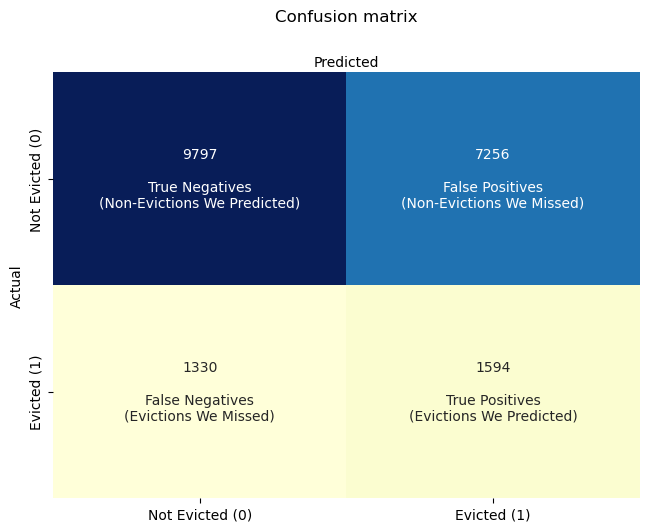

In [21]:
demo12.confusion_matrix(y_test, y_pred)

# Assessing Model "Fit"

This is always going to be a balance between more and less sensitivity to the outcome you want to predict.

Do you want more or fewer false alarms? How much do you want to "cry wolf"?

### Accuracy
Proportion of classifications that are correct.

$$
Accuracy = \frac{Correct Classifications}{Total Classifications} = \frac{True Positives + True Negatives}{True Positives + True Negatives + False Positives + False Negatives}
$$

### Precision/Specificity
Proportion of positive predictions that are correct.

You want precision to be high if it's bad to have false positives (e.g., if unnecessary identification and treatment is costly).

$$
Precision = \frac{True Positives}{True Positives + False Positives}
$$

### Recall/Sensitivity/True Positive Rate
Proportion of actual positives that are predicted correctly.

You want recall to be high if it's bad to have false negatives (e.g., if you would rather identify and treat even if it's not strictly necessary).

$$
Recall = \frac{True Positives}{True Positives + False Negatives}
$$

In [22]:
threshold = 0.2

y_pred = predict_with_threshold(logreg, X_test, threshold)
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print(f'Accuracy:   {accuracy:.2f}  (% of predictions that are correct)')
print(f'Precision:  {precision:.2f}  (% of predicted evictions that are correct)')
print(f'Recall:     {recall:.2f}  (% of actual evictions that are predicted correctly)')


Accuracy:   0.82  (% of predictions that are correct)
Precision:  0.29  (% of predicted evictions that are correct)
Recall:     0.15  (% of actual evictions that are predicted correctly)


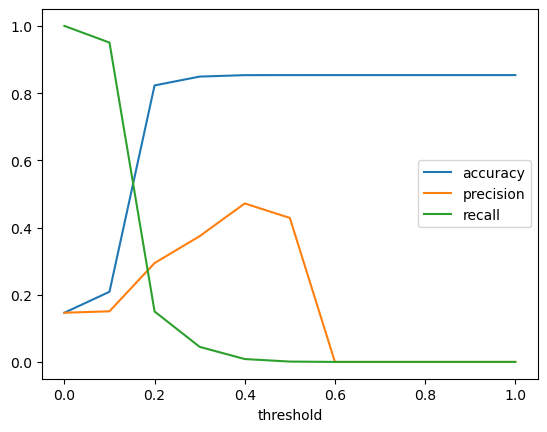

In [23]:
demo12.plot_fit_stats(logreg, X_test, y_test)

### Receiver Operating Characteristic (ROC) Curve

Built by iterating classification thresholds between 0 and 1, then plotting sensitivity against specificity for the resulting outcomes.

Shows the performance of the model at all possible classification thresholds.

The closer the curve is to a right angle, the better the model.

Area Under the Curve (AUC) summarizes performance; better models approach 1.0.

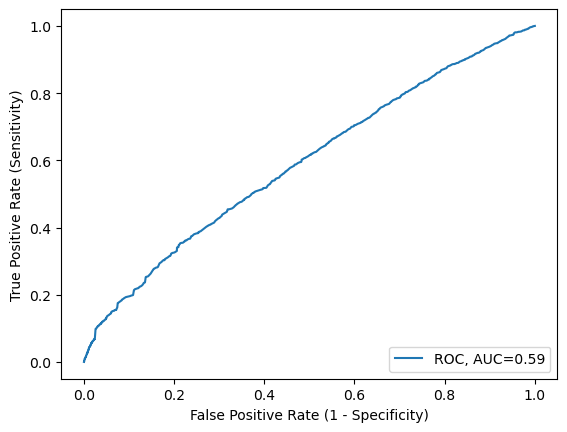

In [24]:
demo12.roc_plot(logreg, y_test, X_test)

# Random Forest (Tree-Based Classifer)

Based on decision trees:

<img alt="Gini impurity visualization" src='https://media.geeksforgeeks.org/wp-content/uploads/20250408153824016146/predicting_whether_a_customer_will_buy_a_product.webp' width="600">

[Source: https://www.geeksforgeeks.org/machine-learning/decision-tree-introduction-example/](https://www.geeksforgeeks.org/machine-learning/decision-tree-introduction-example/)

Trees are constructed by minimizing Gini Impurity at each node:

<img alt="Gini impurity visualization" src='https://www.pythonalchemist.com/_next/image?url=%2Fimages%2Fcovers%2Fgini-impurity-visualizer.webp&w=1920&q=75' width="600">

[Source: https://williamkoehrsen.medium.com/random-forest-simple-explanation-377895a60d2d](https://williamkoehrsen.medium.com/random-forest-simple-explanation-377895a60d2d)

A random forest is a collection of (many, many) decision trees:

<img alt="Random forest decision tree example" src='https://miro.medium.com/v2/resize:fit:1184/format:webp/1*i0o8mjFfCn-uD79-F1Cqkw.png'>

[Source: https://www.pythonalchemist.com/blog/gini-impurity-visualizer](https://www.pythonalchemist.com/blog/gini-impurity-visualizer)

If you want to dive deeper into decision trees and to train them, [this is an excellent YouTube primer.](https://www.youtube.com/watch?v=B6a64wdD7Zs)
## Train

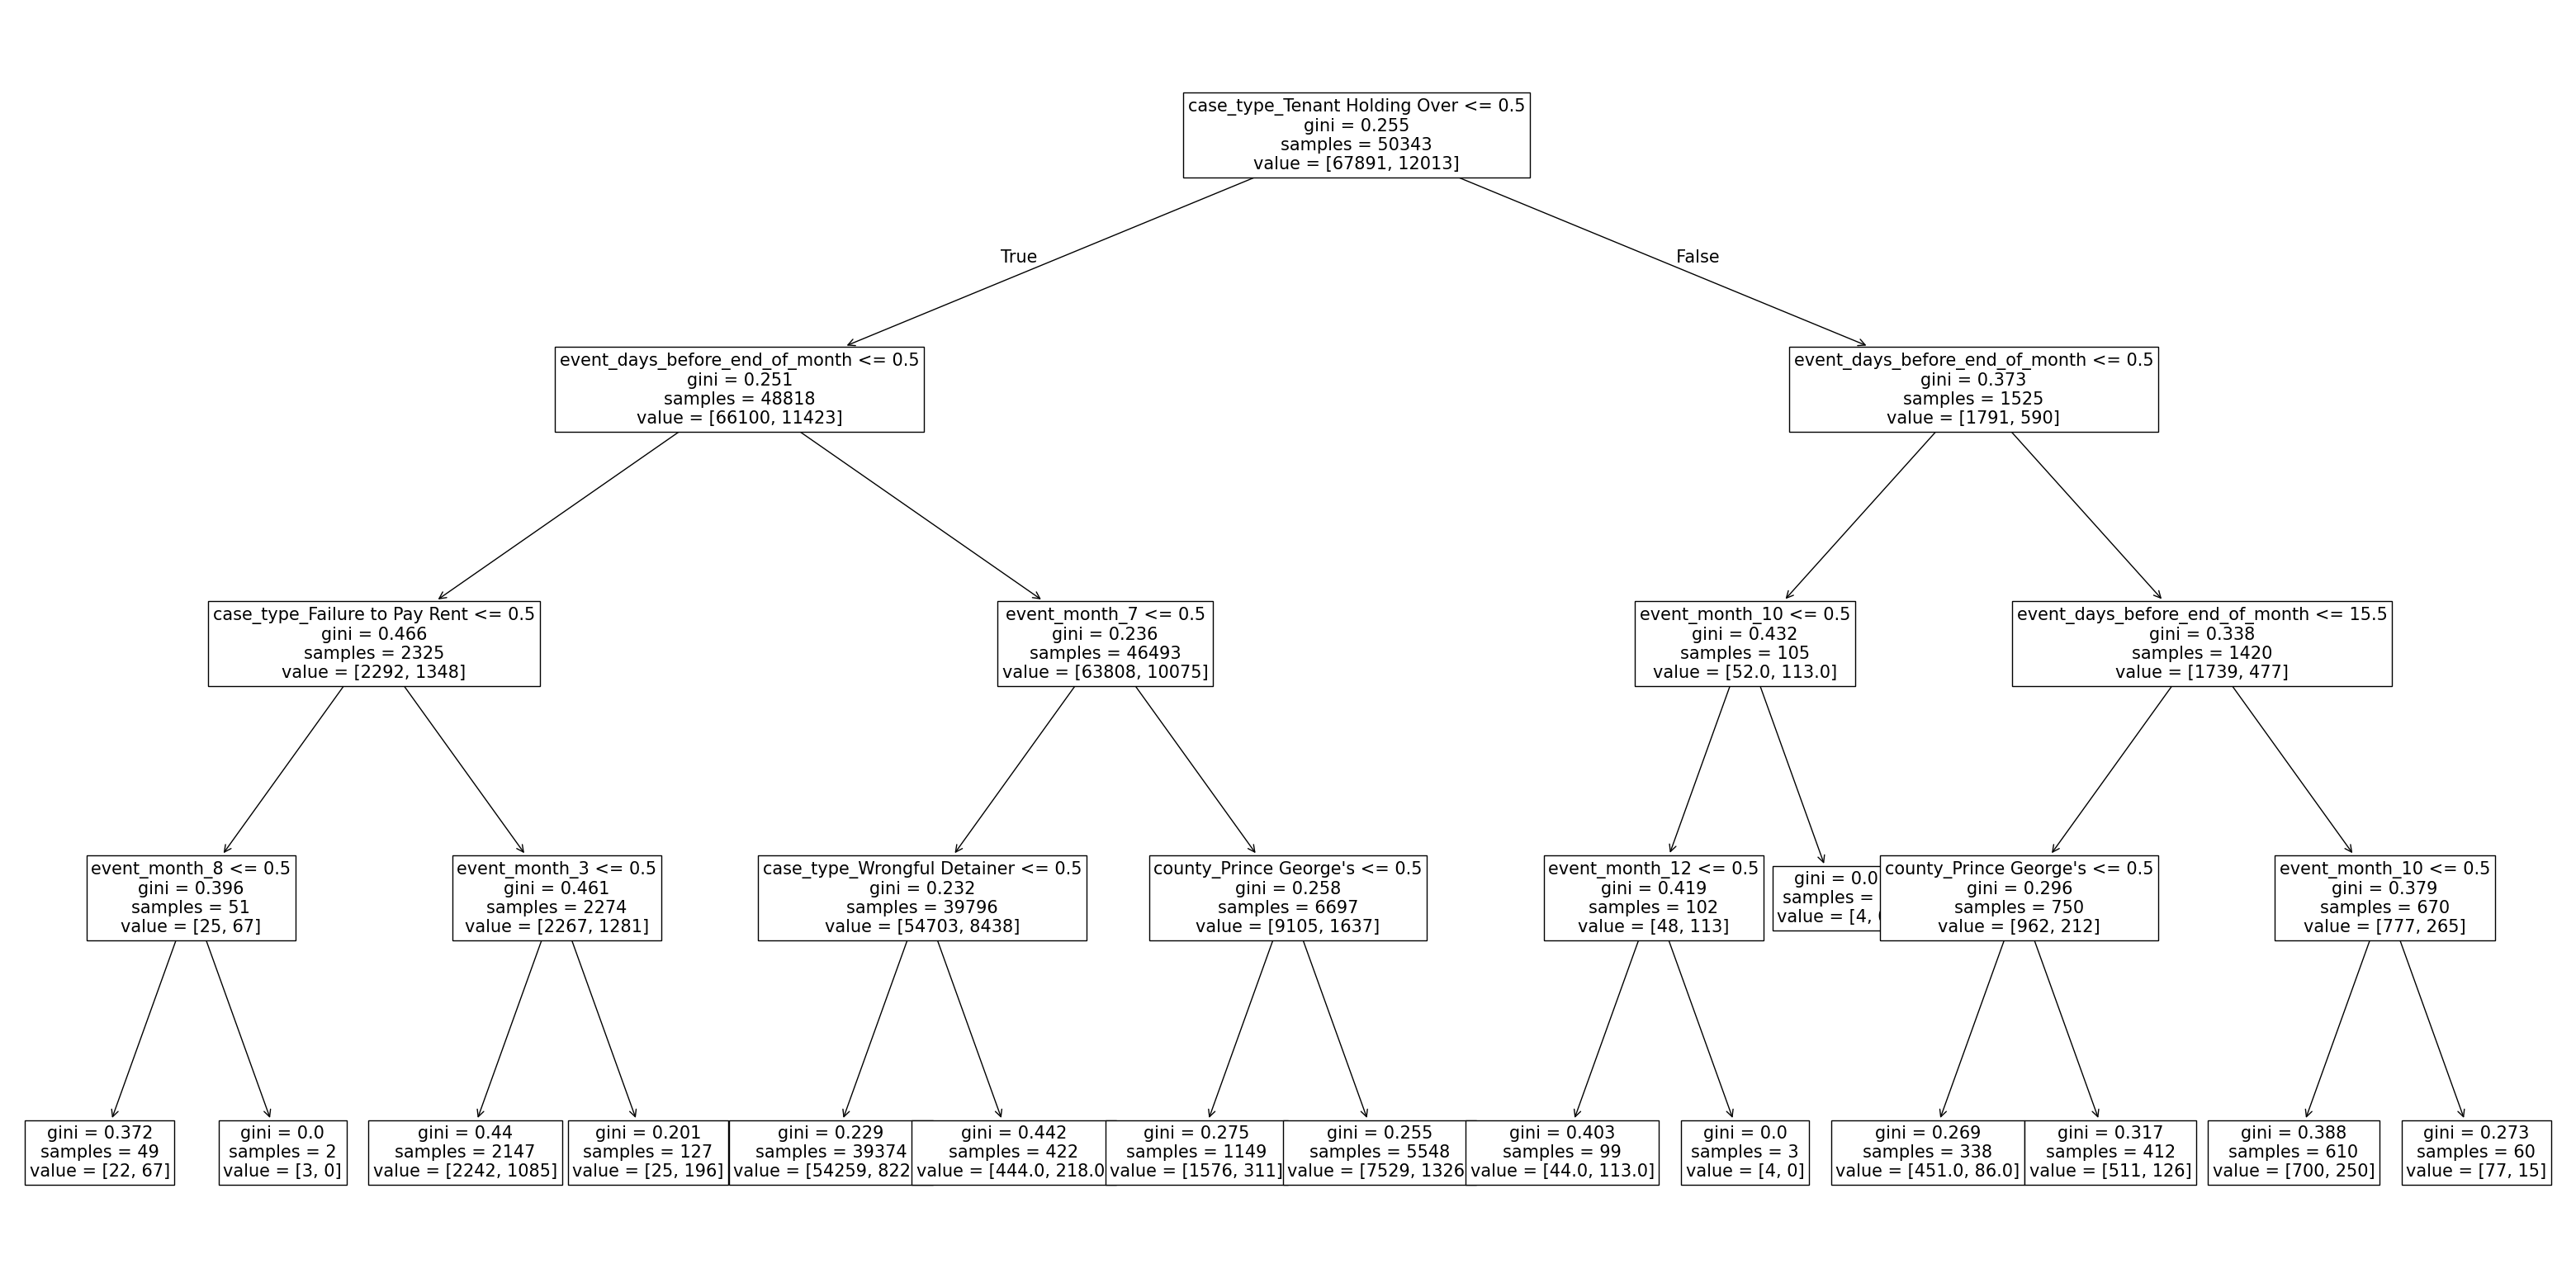

In [25]:
# Initialize the random forest classifer object
rf = RandomForestClassifier(n_estimators = 50, random_state = 1, n_jobs=-1, max_depth=4) 

# Fit the model based on training data
rf.fit(X_train, y_train)

# Visualize the first estimator/tree
e = rf.estimators_[0]

fig, ax = plt.subplots(figsize=(40,20))  
_ = tree.plot_tree(e, feature_names = X_train.columns, fontsize=15, ax = ax)

In [26]:
## Now let's allow the depth of decision trees to be unlimited
## (Nodes are expanded until each leaf contains one observation)

# Initialize the random forest classifer object
rf = RandomForestClassifier(n_estimators = 100, random_state = 1, max_depth=None)

# Fit the model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Test

In [27]:
y_pred = rf.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(19977,))

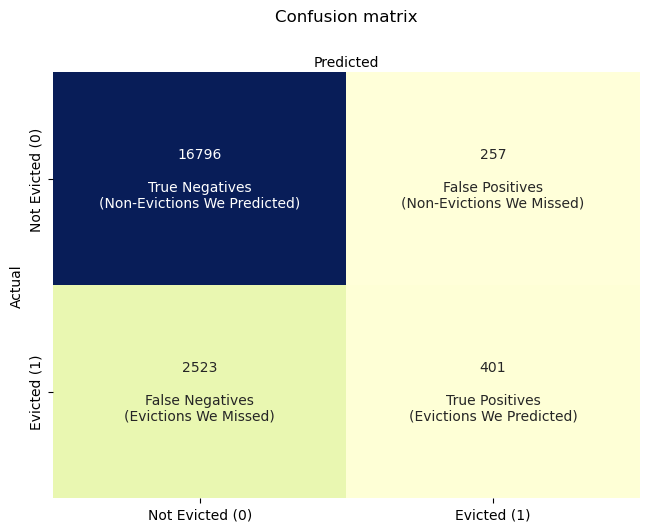

In [28]:
demo12.confusion_matrix(y_test, y_pred)

In [29]:
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print(f'Accuracy:   {accuracy:.2f}  (% of predictions that are correct)')
print(f'Precision:  {precision:.2f}  (% of predicted evictions that are correct)')
print(f'Recall:     {recall:.2f}  (% of actual evictions that are predicted correctly)')

Accuracy:   0.86  (% of predictions that are correct)
Precision:  0.61  (% of predicted evictions that are correct)
Recall:     0.14  (% of actual evictions that are predicted correctly)


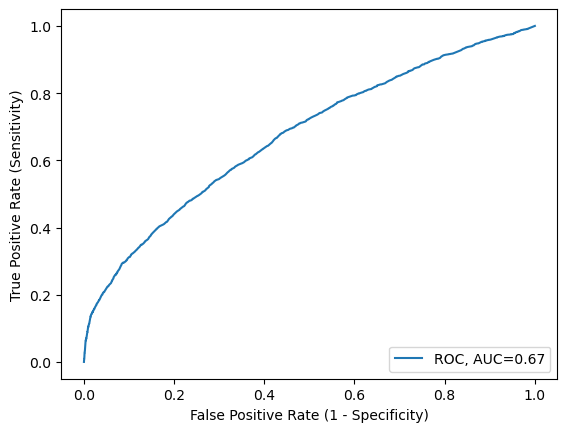

In [30]:
demo12.roc_plot(rf, y_test, X_test)

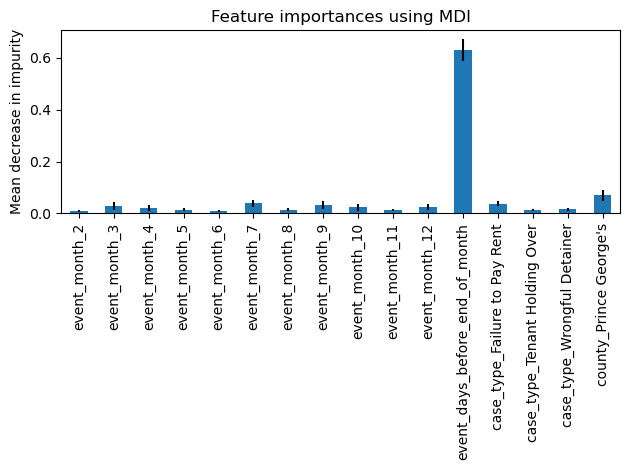

In [31]:
# Investigate feature importance with mean decrease in impurity (MDI)

importances = pd.Series(rf.feature_importances_, index=X_test.columns)
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
fig, ax = plt.subplots()
importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()